# Running QAOA on IQM Radiance @ LRZ

LRZ's Euro-Q-Exa is a 53-qubit IQM Radiance machine suitable for general-purpose quantum algorithms. A key example is solving MaxCut on 3-regular graphs using the Quantum Approximate Optimization Algorithm (QAOA). 

QAOA is a variational quantum algorithm designed to solve combinatorial optimization problems. 

In this notebook, we will learn how ...
* ... QAOA works.
* ... to run QAOA on EQE using the Munich Quantum Software Stack.
* ... to use tools from `iqm-qaoa` package to easily set up and solve problems with QAOA.

`iqm-qaoa` documentation can be found [here](https://docs.meetiqm.com/iqm-qaoa/). (This link may not work until a few days after the presentation. If it does not work, please try [this one](https://docs.meetiqm.com/sdk4_3/iqm-qaoa/) instead.)

In order to follow this example or start experimenting with your own problems using EQE, make sure to have all packages in the appropriate version installed.

In [ ]:
%%capture
!pip install iqm-qaoa

Let's connect to EQE via MQSS. We'll need a token to authenticate:

In [12]:
from mqss.qiskit_adapter import MQSSQiskitAdapter

adapter = MQSSQiskitAdapter(
    token="BG5j96k77R0thZwLV2VIuCRXxYNfokED9kGMJRyYGVZNzd2mjMlaw5WWugWoKAo2"
)

backend=adapter.get_backend('EQE1')

## Problem instance

For the purpose of this demonstration, we will solve a MaxCut problem. MaxCut is an NP-hard problem, with applications in clustering, communication analysis, network science, and statistical physics. Conveniently, it also serves as a great showcase on how quantum optimization algorithms like QAOA work. 

With MaxCut, we are given a graph. We want to find a way to divide the vertices into two subsets (below colored red and green) that maximizes the "cut size," that is, the number of edges that connect different subsets.

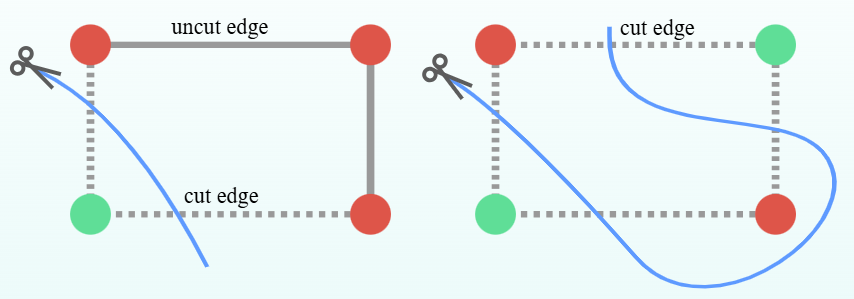

To begin, let's choose a graph to find the maximum cut for. We generate a random regular graph with 8 nodes and a degree of 3 (n=8, d=3). This is very easy using `iqm-qaoa`.

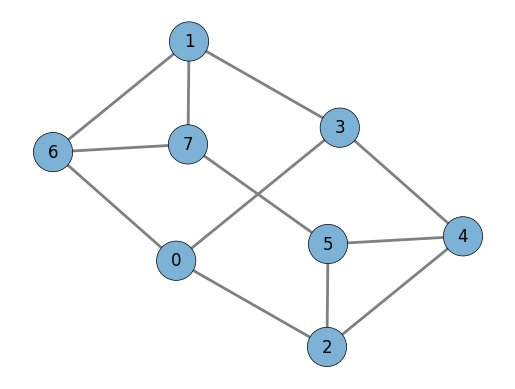

In [13]:
from iqm.applications.maxcut import maxcut_generator
import networkx as nx

my_maxcut_problem = next(maxcut_generator(n=8, n_instances=1, graph_family="regular", d=3, seed=999))

G = my_maxcut_problem.graph

my_maxcut_problem.draw_problem()

Each node in the graph will be represented by a qubit, and a quantum state like $\ket{00001111}$ represents a cut. Specifically, this state means that nodes 0-3 are in one group (labeled by the quantum state $\ket{0}$ for each qubit) and nodes 4-7 are in the other group (labeled by the quantum state $\ket{1}$ for each qubit).

## Solving MaxCut using QAOA and IQM Radiance

At the heart of the Quantum Approximate Optimization Algorithm (QAOA) is a parametrized quantum circuit designed to tackle complex optimization problems, like the MaxCut problem. The QAOA circuit is designed to efficiently explore the solution space of a given problem. It is composed of a series of alternating layers of single-qubit rotations and two-qubit interactions. By adjusting the parameters in the circuit, QAOA aims to find the optimal configuration that maximizes or minimizes a specific objective function. In this case, our objective function is the cut value.

QAOA starts from a **problem Hamiltonian**, which is a quantum operator defined to measure the (negative of the) objective function applied to any given state. The aim of QAOA is to find a quantum circuit which approximately prepares the lowest-energy state of  the problem Hamiltonian, that is, to approximate the optimal solution of the combinatorial problem. 

The dynamics of the problem Hamiltonian are encoded in a quantum computer by a circuit representing the **problem unitary**. Correspondingly, a circuit representing the so-called **mixer unitary** is used to explore more possible solutions to the problem. By alternating between the application of the problem unitary and the mixer unitary, QAOA evolves the quantum system toward the ground state of the problem Hamiltonian, which corresponds to the optimal solution of the combinatorial problem.

Each layer of the problem unitary and mixer unitary come with a parameter, which is traditionally classically optimized in order to minimize the expectation value of the problem Hamiltonian. This helps us get closer to its ground state.

Let's create a QAOA ansatz with a single layer and inspect it. This can be done automatically and easily in `iqm-qaoa`:

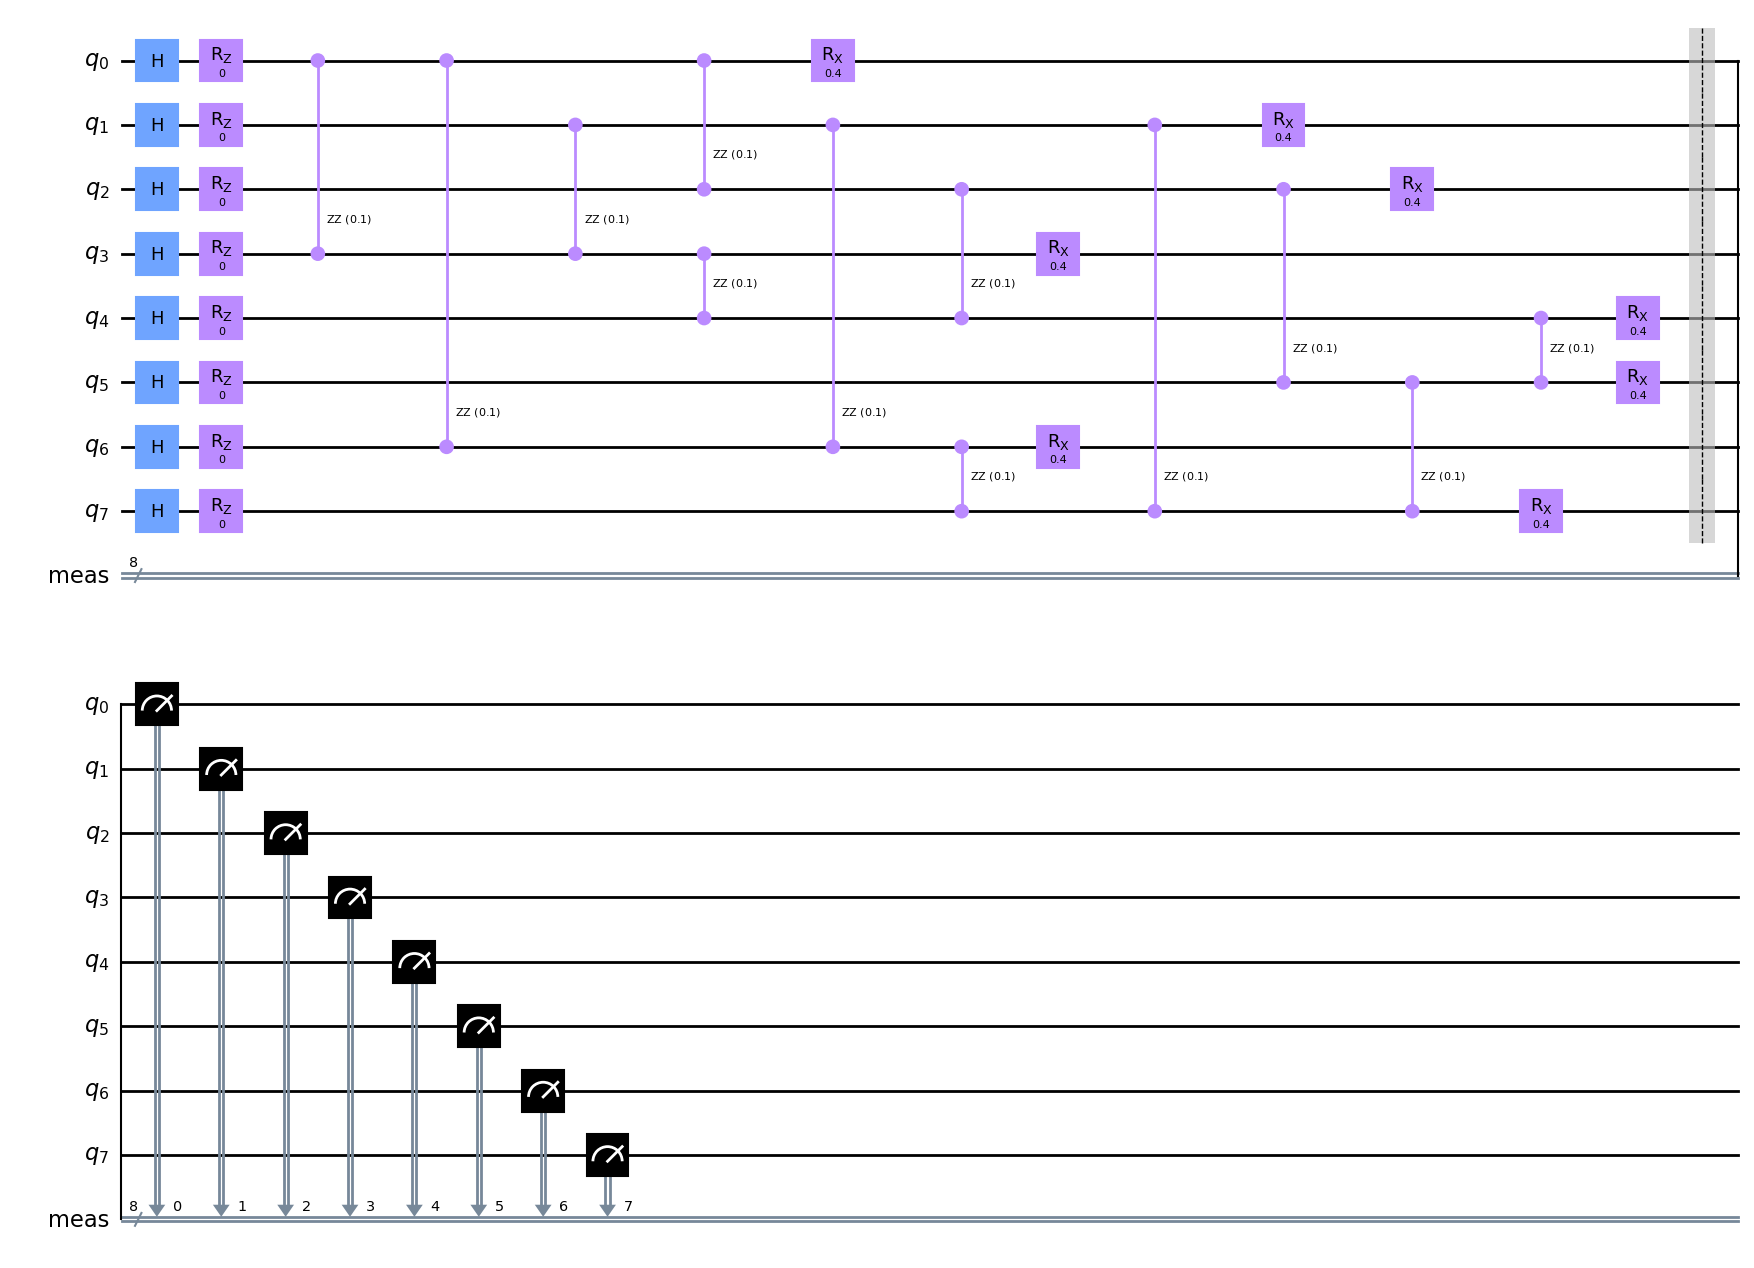

In [4]:
from iqm.qaoa.qubo_qaoa import QUBOQAOA   # most generic QAOA problem setup, which we won't use here
from iqm.qaoa.tree_qaoa import TreeQAOA   # same as QUBOQAOA, but for special cases like regular graphs, this enables one more method for training angles (see below)
from iqm.qaoa.circuits import qiskit_circuit

my_qaoa = TreeQAOA(problem=my_maxcut_problem, num_layers=1, initial_angles=[0.1, 0.2])

qc_perfect = qiskit_circuit(my_qaoa, measurements=True)

qc_perfect.draw("mpl", style="clifford", idle_wires=False)

Above, the first layer of Hadamard gates initializes the quantum system in a uniform superposition state, that ensure that every possible solution is equally represented when starting to explore the solution space.

The two-qubit ZZ rotations encode the problem hamiltonian. One is applied for each pairs of qubits that are connected by an edge in the problem graph. The single-qubit Z rotations allow us to solve problems with local bias terms (i.e. MaxCut-like problems where edges have different weights) in addition to edge terms.  Since, there are no such terms in MaxCut, they have zero angle here.

The final RX rotations on each qubit form the *mixer unitary*. They enable the QAOA to explore different solutions. In the language of physics, this can be interpreted as applying a transversal magnetic field to all our spins for some amount of time.

This combination (of mixer and problem circuit) we call a **layer of the QAOA ansatz**. Increasing the number of layers (or the depth of the circuit), allows QAOA to explore a larger portion of the solution space. However more noise gets added to the computation from every gate applied. Finding the optimal number of layers is often a balance between desired solution quality, the classical computational resources available, the gate fidelities and the wall-clock time available for the computation. In practice, QAOA users typically experiment with different depths to determine the most effective trade-off between runtime and solution quality for a given optimization problem.

We can easily add more layers by changing the `num_layers` argument in the `QUBOQAOA` object. Finally, instead of the arbitrarily chosen `initial_angles=[0.1, 0.2]` we want to find gate parameters for ZZ and RX gates that lead to best solutions.



### Finding optimal QAOA angles

In order to find the best angle parameters $\gamma$ and $\beta$, one typically keeps measuring the average value of the cost function (cut edges for MaxCut) for different angles according to some classical optimization protocol (such as gradient descent) until the result no longer improves. This is similar to the training of neural networks. 

This is so called quantum-classical loop is the most resource consuming part of QAOA. An important part of the `iqm-qaoa` package is a set of tools allowing one to find these angles without quantum computer. Only the final measurement of the optimal solution still has to be done with a quantum computer. Below we utilize the **parameter concentration** phenomenon of QAOA to find $\gamma$ and $\beta$. In a nutshell: for many types of problems, the optimal parameters are found to be independent of the problem size (number of nodes in the graph). Thanks to this fact we can fetch the optimal angles from a pre-computed table of values for given graph regularity and number of QAOA layers. For regular graphs, the classical pre-computing of optimal angles even for deep QAOA circuits is possible due to the fact that small loops vanish or conversely tree-structures emerge. Hence this powerful method is called `treeQAOA` in `iqm-qaoa`. For more information see:            


#### Try different training methods below

In [ ]:
from iqm.qaoa.backends import EstimatorFromSampler, EstimatorSingleLayer, EstimatorStateVector, EstimatorQUIMB, SamplerResonance, SamplerSimulation
from iqm.qiskit_iqm import IQMFakeAdonis, IQMFakeApollo, IQMFakeAphrodite, IQMFakeDeneb # 5, 20 and 54 qubit noisy simulators, respectively (Deneb = 6 qubit star)

# a)
my_qaoa.set_tree_angles()

# b)
#estimator = EstimatorSingleLayer()  # default if num_layers=1
# c) 
#estimator = EstimatorStateVector()  # default if num_layers > 1
# d) 
#estimator = EstimatorQUIMB()  # Tensor network simulator
# e)
#estimator = EstimatorFromSampler(sampler=SamplerSimulation(), shots=20_0000) # By default, initializes AerSimulator(method="statevector")
# f)
#estimator = EstimatorFromSampler(sampler=SamplerSimulation(IQMFakeAphrodite(), transpiler="Default") , shots=10_000)
# g)
#IQM_TOKEN = input("Input your IQM Resonance token")
#IQM_URL = "https://resonance.meetiqm.com/garnet"
#estimator = EstimatorFromSampler(sampler=SamplerResonance(token=IQM_TOKEN, server_url=SERVER_URL, transpiler="Default"), shots=10_000)
# h)
#IQM_TOKEN = input("Input your IQM Resonance token")
#IQM_URL = "https://resonance.meetiqm.com/garnet"
#estimator = EstimatorFromSampler(sampler=SamplerResonance(token=IQM_TOKEN, server_url=SERVER_URL, transpiler="Default"), shots=10_000, cvar=0.1)

# IMPORTANT: if you are using any method other than set_tree_angles, uncomment this next line!
#my_qaoa.train(estimator=estimator)

QAOA depth p =  1
Tree angles for d =  3  rounded from  3.0 ,[input] and h =  0.0  near  0.0  [input] (rescaled by average j_av =  0.5 )


### Measuring the optimized ansatz on Euro-Q-Exa
Having found good angles for the QAOA ansatz, we now create this quantum state on EQE and measure it multiple times to find our (approximate) solution to the MaxCut problem.

Executing the ansatz circuit on EQE is really simple with `iqm.qaoa`. The method `qiskit_circuit` outputs a Qiskit version of the trained circuit, which can then be run on EQE like any other quantum circuit:

#### Try different sampling methods (EQE + simulations) below

In [15]:
from iqm.qaoa.circuits import qiskit_circuit
from qiskit import transpile

# a) Use IQM @ EQE for sampling
circuit = qiskit_circuit(my_qaoa) # Convert to a Qiskit circuit
##Optionally: transpile for EQE and draw the transpiled circuit
# transpiled_circuit = transpile(circuit,backend=backend) # Optionally: transpile for EQE
# transpiled_circuit.draw("mpl", idle_wires=False)

job = backend.run(circuit, shots=20_000) # Sample on hardware

# b) Use a simulator for sampling
# sampler=SamplerSimulation()
# counts = my_qaoa.sample(sampler, shots=20_000)
# c) Use a noisy quantum simulator for sampling
# sampler=SamplerSimulation(IQMFakeAphrodite())
# counts = my_qaoa.sample(sampler, shots=20_000)

In [17]:
print(job.status())


JobStatus.DONE


Once the job finishes, we can process the results. Only run this next cell if you're using the actual quantum computer as the sampler.

In [18]:
result = job.result()
counts = result.get_counts()
# Running on hardware reverses the bitstrings, so let's fix that
counts = {key[::-1]: value for key, value in counts.items()}

## Investigating the solutions found by QAOA

We can first visualize the counts found by sampling our QAOA circuit. Ideally, solutions with high cut size will appear in the most counts.

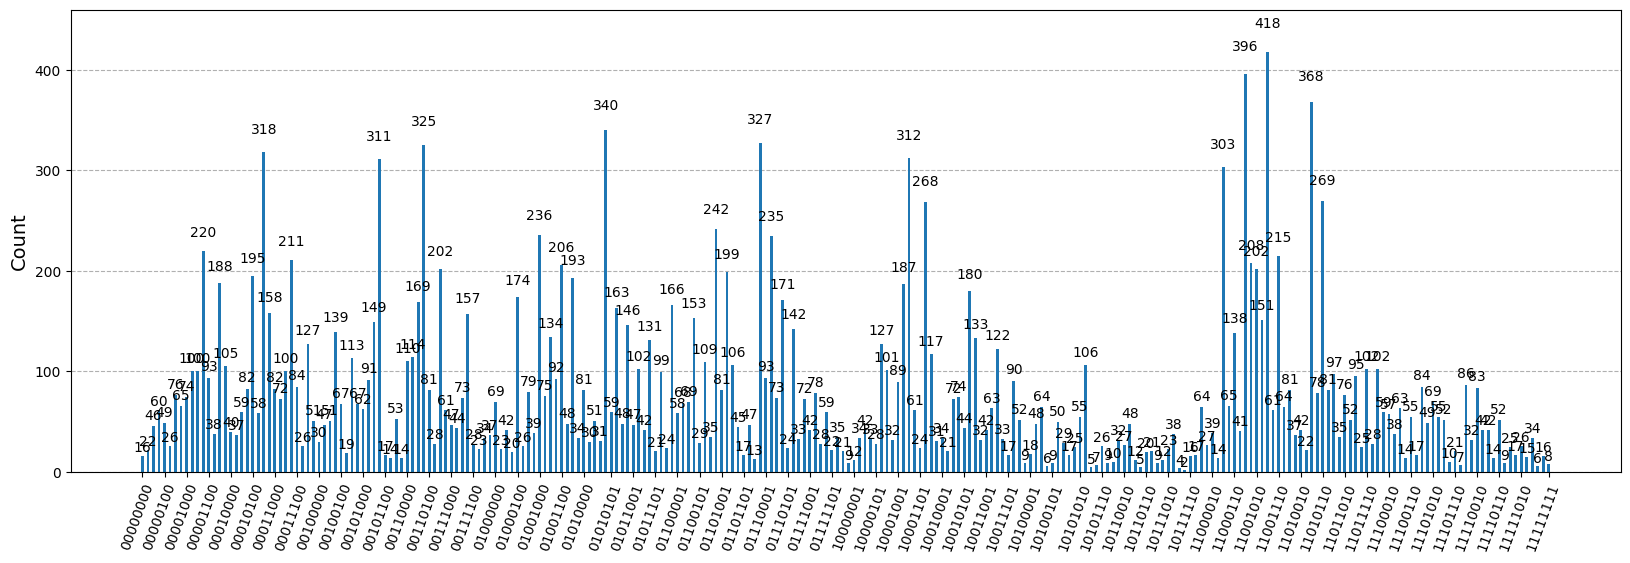

In [19]:
# Plot the results
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(20, 6))
plot_histogram(counts, ax=ax)

desired_ticks = 2**6   ### decreasing the total number of tick labels to have a clean figure
x_ticks = np.linspace(0, len(counts)-1, desired_ticks, dtype=int)
ax.set_xticks(x_ticks)

plt.show()

We can check the cut size of the top few found solutions very easily using the `my_maxcut_problem.quality()` method in the `iqm-qaoa` package.

Then we can compare to the best possible solution, found by checking all possible bitstrings using the `greedy_max_cut` function. To find the best solution bitstring we use `greedy_max_cut` function. Note that the leading classical algorithm by *Goemans and Williamson* is also readily available from `iqm.applications.maxcut.goemans_williamson`:

The top 5 results are  [('11001100', 418), ('11001000', 396), ('11010100', 368), ('01010100', 340), ('01110000', 327)]
The best found cut is given by 11001100 with a cut size of 10.0
The maximum cut is given by 00110011 with a cut size of 10.0


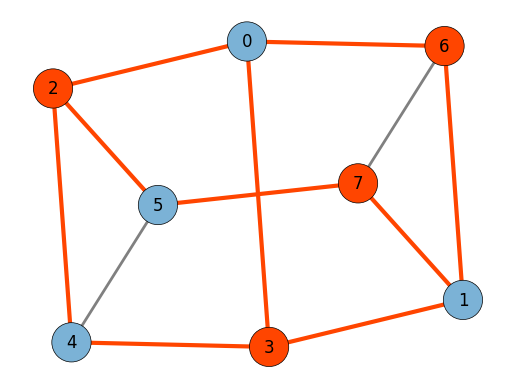

In [20]:
from iqm.applications.maxcut import greedy_max_cut

# Sort the counts by their values in descending order
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

num_results = 5
# Get the top X results
top_n_results = sorted_counts[:num_results]

print("The top", num_results, "results are ",  top_n_results)
results=[]
for res in top_n_results:
    results.append([my_maxcut_problem.quality(res[0]), res[0]])

# Get the best solution given the results of the maxcut objective function
max_cut_size, max_cut = min(results) 
print("The best found cut is given by " + max_cut + " with a cut size of " + str(-max_cut_size))
print("The maximum cut is given by " + greedy_max_cut(my_maxcut_problem) + " with a cut size of " + str(-my_maxcut_problem.best_quality))

solution_aux = [int(x) for x in max_cut]
solution = solution_aux[::-1]

my_maxcut_problem.draw_problem(''.join(map(str, solution)))

**Exercises:**

1. If you are using simulators, try different transpilers available in `iqm-qaoa`:   
"Default",  
"HardwiredTranspiler",  
"SparseTranspiler",  
"SwapNetwork"  
"MinimumVertexCover" (only for Sirius)  
  
2. Try different methods of finding/training QAOA angles available in `iqm-qaoa`:     
`EstimatorFromSampler`,  
`EstimatorSingleLayer`,  
`EstimatorStateVector`,  
`EstimatorQUIMB`,  
`SamplerResonance`  - also try optimizing cvar instead of average energy (works also with `SamplerSimulation`) ,   
`SamplerSimulation`  - try with Aer and with noisy simulator

3. Try different Samplers available in `iqm-qaoa` to obtain the solution bitstring:  
`SamplerResonance`    
`SamplerSimulation`  - try with Aer and with noisy simulator

4. Change the number of QAOA layers and qubits

In [ ]:

# Copyright 2026 IQM Quantum Computers (Daniel Bulmash, Jami Rönkkö, Jalil Khatibi Moqadam,  Jiri Guth Jarkovsky, Stefan Seegerer, Hermanni Heimonen)
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.